# Assignment 14: Principal Component Analysis (PCA) and Clustering

**Name:** Ashar Khan
**Batch:** Data Science Weekday – Hyderabad  
**Topic:** PCA & Clustering Analysis

## Importing Required Libraries

In this step, we import all the necessary libraries required for data analysis, visualization, dimensionality reduction, and clustering.

Pandas and NumPy are used for data handling and numerical operations. Matplotlib and Seaborn are used for data visualization. Scikit-learn provides tools for preprocessing (StandardScaler), dimensionality reduction (PCA), clustering (KMeans), and evaluation metrics such as silhouette score.

These libraries form the foundation for performing machine learning and data analysis tasks efficiently.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Loading the Dataset

In this step, we load the dataset into the notebook using pandas. The dataset contains multiple numerical features that describe different properties of wine.

After loading, we display the first few rows using head() to understand the structure of the dataset. Proper loading ensures that the data is correctly imported and ready for further analysis.

In [2]:
df = pd.read_csv(r"/content/wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## Data Understanding

Here, we explore the dataset to understand its structure, data types, and statistical properties.

- info() helps us check data types and detect missing values  
- describe() provides summary statistics such as mean, min, max, and standard deviation  
- isnull().sum() helps identify missing values  

Understanding the dataset is important before applying any transformations or models.

In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


## Exploratory Data Analysis (EDA)

EDA helps us understand the distribution and patterns in the dataset.

- Histograms show how features are distributed  
- Box plots help identify outliers  
- These insights help us understand whether preprocessing is required  

EDA is an important step before applying PCA and clustering algorithms.

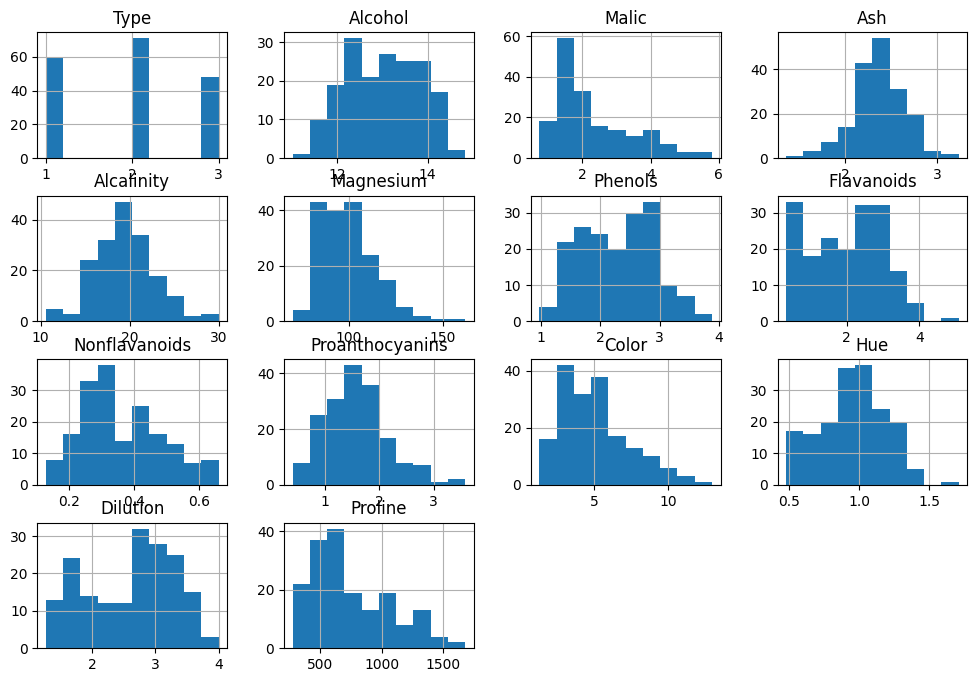

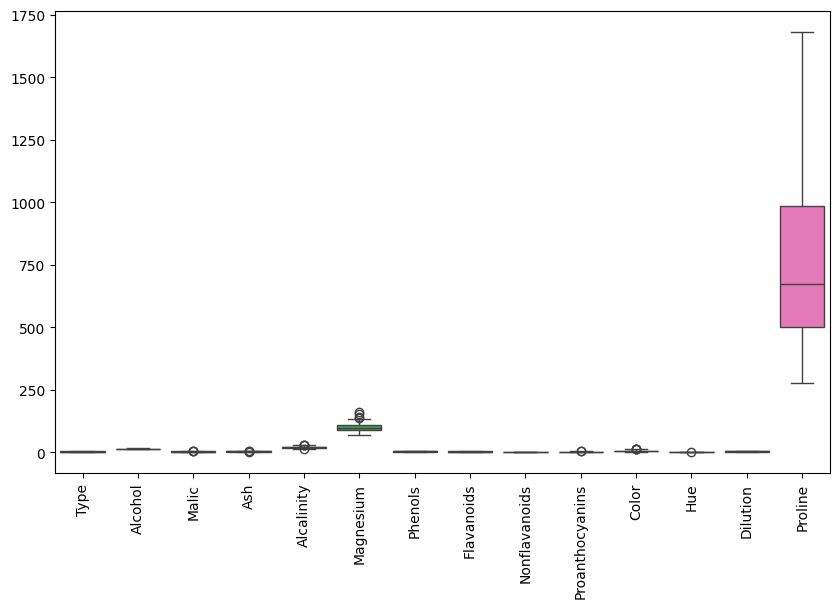

In [4]:
df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

## Correlation Analysis

Correlation analysis helps us understand relationships between different features.

A heatmap is used to visualize correlation values:
- Values close to +1 → strong positive relationship  
- Values close to -1 → strong negative relationship  
- Values near 0 → weak relationship  

This step helps in identifying redundant features, which is important for dimensionality reduction.

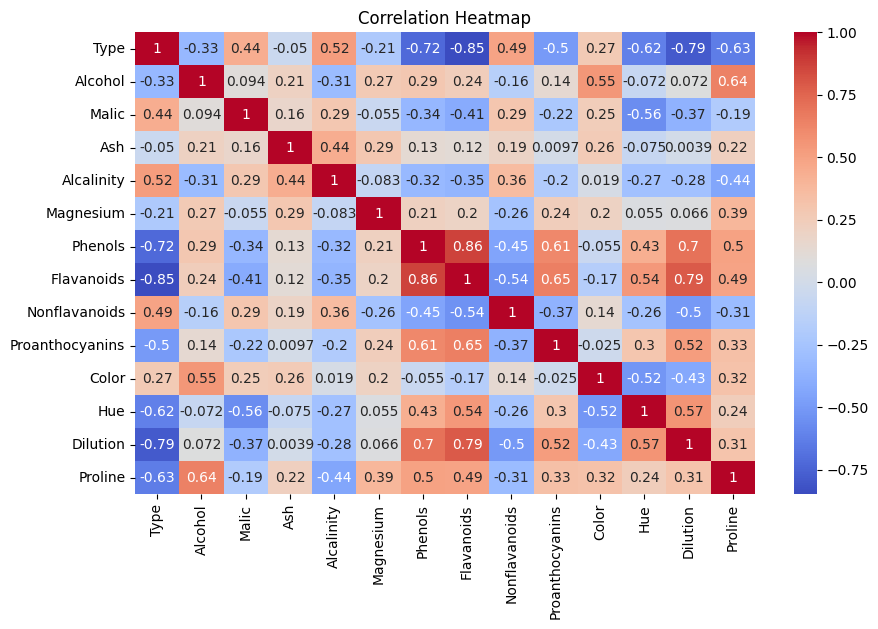

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Feature Scaling

Feature scaling is essential before applying PCA because PCA is sensitive to the scale of features.

We use StandardScaler to:
- Convert features to mean = 0  
- Standard deviation = 1  

This ensures that all features contribute equally to PCA.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Principal Component Analysis (PCA)

PCA is used to reduce the number of features while preserving maximum information.

It transforms original features into new components called principal components:
- PC1 captures maximum variance  
- PC2 captures second highest variance  

This helps reduce dimensionality and improves computational efficiency.

## Explained Variance

Explained variance tells us how much information each principal component retains.

We use a scree plot to:
- Identify how many components are important  
- Choose optimal number of components  

Cumulative variance helps decide how many components to keep (usually 90–95%).

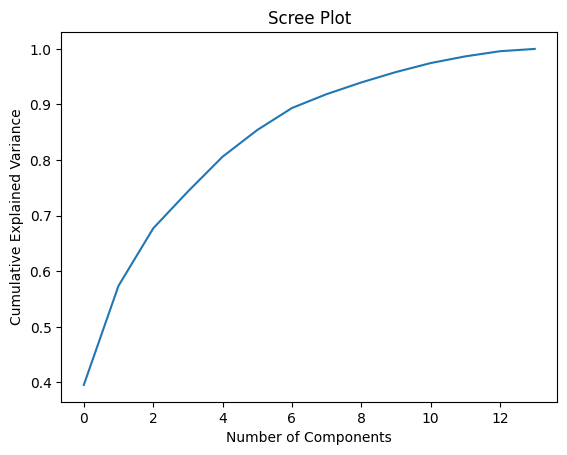

In [7]:
pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot")
plt.show()

## Selecting Optimal Components

Based on the scree plot (cumulative explained variance), we observe that the first few principal components capture most of the variance in the dataset.

The curve starts to flatten after around 2–4 components, indicating diminishing returns from additional components. Therefore, selecting 2 principal components is sufficient for visualization while still retaining a significant portion of the original information.

This reduction helps simplify the dataset while maintaining meaningful patterns.

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

## Clustering on Original Data

In this step, we apply K-Means clustering on the original dataset.

K-Means groups data into clusters based on similarity. We specify the number of clusters (k) and fit the model.

Clustering helps identify hidden patterns in the dataset.

In [9]:
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [ ]:
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_original = kmeans_original.fit_predict(X_scaled)

## Clustering on PCA Data

Here, we apply K-Means clustering on the PCA-transformed dataset.

Since PCA reduces dimensions, clustering becomes faster and sometimes more effective.

In [10]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(X_pca)

## Cluster Visualization

We visualize clusters using scatter plots.

For PCA data, visualization becomes easier because we reduced dimensions to 2 components.

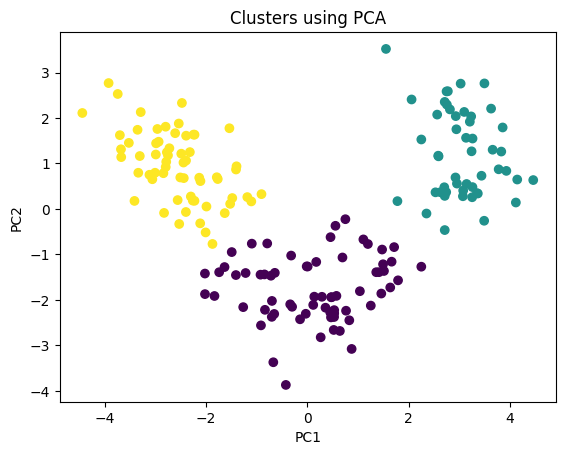

In [11]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_pca)
plt.title("Clusters using PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## Clustering Evaluation

We evaluate clustering performance using the silhouette score. This metric measures how well data points are grouped within clusters.

A score closer to 1 indicates well-separated clusters, while a score near 0 indicates overlapping clusters.

By comparing scores for original data and PCA-transformed data, we can understand the impact of dimensionality reduction on clustering performance.

In [16]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans # Ensure KMeans is imported for local re-definition

# Re-define labels_original from previous cells to resolve NameError
# This assumes X_scaled is already defined from a previous cell execution.
# The 'kmeans_original' object also needs to be available or re-initialized.
# From the notebook state, it seems the previous cell defining kmeans_original was not executed.
# Adding the definition here to make this cell runnable.
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_original = kmeans_original.fit_predict(X_scaled)


print("Original Data Score:", silhouette_score(X_scaled, labels_original))
print("PCA Data Score:", silhouette_score(X_pca, labels_pca))

Original Data Score: 0.30773604383565206
PCA Data Score: 0.6024415520362845


## Comparison and Analysis

Clustering on PCA-transformed data is faster and easier to visualize. However, some information may be lost due to dimensionality reduction.

Original data clustering retains full information but may be computationally expensive.

This shows a trade-off:
- PCA → Faster, simpler, visualizable  
- Original → More detailed, accurate  

The choice depends on dataset size and problem requirements.

## Conclusion

In this assignment, we successfully implemented Principal Component Analysis (PCA) for dimensionality reduction and applied K-Means clustering to both the original dataset and the PCA-transformed dataset. The workflow included data exploration, feature scaling, PCA transformation, clustering, and performance evaluation.

We observed that PCA effectively reduces the dimensionality of the dataset by transforming the original features into a smaller set of principal components while preserving most of the variance (information). This not only simplifies the dataset but also helps in improving computational efficiency and reducing noise.

When comparing clustering results, we found that clustering on PCA-transformed data was faster and easier to visualize due to reduced dimensions (especially in 2D space). However, clustering on the original dataset retains complete information and may sometimes provide slightly more detailed grouping. This highlights an important trade-off between dimensionality reduction and information retention.

The silhouette score comparison helped us evaluate clustering quality and understand how PCA impacts cluster separation. In many cases, PCA can improve clustering performance by removing redundant and highly correlated features.

Overall, this assignment demonstrates the importance of combining dimensionality reduction techniques like PCA with clustering algorithms such as K-Means to analyze high-dimensional data efficiently. These techniques are widely used in real-world applications including customer segmentation, image compression, recommendation systems, and anomaly detection, where handling large and complex datasets is essential.